In [4]:
# ============================================================
# CELL 1 - Install
# ============================================================
!pip install ultralytics transformers -q

In [5]:
# ============================================================
# CELL 2 - Imports
# ============================================================
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw, ImageFont
from transformers import CLIPProcessor, CLIPModel
from ultralytics import YOLO
from sklearn.cluster import DBSCAN
from google.colab import drive
import colorsys, math, os, json
from collections import defaultdict

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

Using: cpu


In [6]:
# ============================================================
# CELL 3 - Config
# ============================================================
CONFIG = {
    # paths
    "model_path"  : "/kaggle/input/datasets/astitwarajawat/yolo-model/best.pt",
    "video_path"  : "/kaggle/input/datasets/astitwarajawat/demo-videos/20260426_201443_1.mp4",

    # frame extraction
    "target_fps"          : 2,     # frames to process per second
    "min_detection_ratio" : 0.5,   # skip frame if detections < 50% of expected
    "blur_threshold"      : 80,    # lower = accept more blur

    # detection
    "conf"        : 0.25,
    "iou"         : 0.45,
    "min_box_size": 20,

    # CLIP clustering
    "clip_eps"       : 0.10,       # lower = stricter grouping
    "clip_min_samp"  : 2,
    "force_threshold": 0.60,       # min similarity to assign unmatched crop

    # stock thresholds
    "low_stock_pct" : 0.40,        # below 40% of group baseline = LOW STOCK
}

In [7]:
# ============================================================
# CELL 4 - Load models
# ============================================================
shelf_model = YOLO(CONFIG["model_path"])

clip_model  = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor   = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval().to(device)

print("Models loaded!")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Models loaded!


In [8]:
# ============================================================
# CELL 5 - Frame extraction with quality filtering
# No person detector — low product count = obstruction
# ============================================================

def extract_and_filter_frames(video_path, config):
    """
    Process video at target_fps.
    Filter frames where product count drops below
    50% of the expected count (person / obstruction).
    Returns only usable frames with pre-computed boxes.
    """
    target_fps    = config.get("target_fps", 2)
    min_det_ratio = config.get("min_detection_ratio", 0.5)

    cap       = cv2.VideoCapture(video_path)
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    total     = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration  = total / video_fps
    step      = max(1, int(video_fps / target_fps))

    print(f"Video   : {duration:.1f}s  |  {video_fps:.1f} fps  |  {total} frames")
    print(f"Sampling: every {step} frames  ({target_fps} fps effective)")

    all_frames = []
    frame_idx  = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % step == 0:
            ts        = frame_idx / video_fps
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # cheap blur check first (no YOLO)
            gray       = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
            blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

            if blur_score < config.get("blur_threshold", 80):
                all_frames.append({
                    "frame": frame_rgb, "timestamp": ts,
                    "usable": False, "reason": f"Blurry ({blur_score:.0f})",
                    "n_det": 0, "boxes": []
                })
                frame_idx += 1
                continue

            # run shelf YOLO once per frame
            results = shelf_model(
                frame_rgb,
                conf=config["conf"],
                iou=config["iou"],
                verbose=False
            )[0]

            boxes = []
            for box in results.boxes.xyxy.cpu().numpy().astype(int):
                x1, y1, x2, y2 = box
                if ((x2-x1) >= config["min_box_size"] and
                    (y2-y1) >= config["min_box_size"]):
                    boxes.append((x1, y1, x2, y2))

            all_frames.append({
                "frame": frame_rgb, "timestamp": ts,
                "usable": None, "reason": "OK",
                "n_det": len(boxes), "boxes": boxes
            })

        frame_idx += 1

    cap.release()

    if not all_frames:
        print("No frames extracted")
        return [], []

    # use 75th percentile detection count as expected baseline
    det_counts = [f["n_det"] for f in all_frames if f["usable"] is not False]
    expected   = np.percentile(det_counts, 75) if det_counts else 0
    print(f"\nExpected product count (75th percentile): {expected:.0f}")

    usable, unusable = [], []
    for f in all_frames:
        if f["usable"] is False:
            unusable.append(f)
            continue
        ratio = f["n_det"] / expected if expected > 0 else 0
        if ratio < min_det_ratio:
            f["usable"] = False
            f["reason"] = (f"Low detections {f['n_det']}"
                           f" ({ratio*100:.0f}% of expected {expected:.0f})"
                           f" — possible obstruction")
            unusable.append(f)
        else:
            f["usable"] = True
            usable.append(f)

    print(f"Usable  : {len(usable)}  |  Filtered: {len(unusable)}")
    return usable, unusable

In [9]:
# ============================================================
# CELL 5B - CLIP embedding + clustering helpers
# ============================================================

def get_clip_embeddings(crops, batch_size=32):
    if not crops:
        return np.array([])
    all_emb = []
    for i in range(0, len(crops), batch_size):
        batch  = [Image.fromarray(c) for c in crops[i:i+batch_size]]
        inputs = processor(images=batch, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = clip_model.vision_model(pixel_values=inputs["pixel_values"])
            emb = clip_model.visual_projection(out.pooler_output)
        emb = emb / emb.norm(dim=-1, keepdim=True)
        all_emb.append(emb.cpu().numpy())
    return np.vstack(all_emb)


def cluster_crops(embeddings, config):
    if len(embeddings) == 0:
        return []
    labels     = DBSCAN(
        eps=config["clip_eps"],
        min_samples=config["clip_min_samp"],
        metric="cosine"
    ).fit(embeddings).labels_.tolist()

    # assign unmatched to nearest group
    sim_matrix = embeddings @ embeddings.T
    for i, label in enumerate(labels):
        if label != -1:
            continue
        best_group, best_sim = None, -1
        for j, other in enumerate(labels):
            if other == -1 or i == j:
                continue
            s = float(sim_matrix[i][j])
            if s > best_sim:
                best_sim, best_group = s, other
        if best_group is not None and best_sim >= config["force_threshold"]:
            labels[i] = best_group
    return labels


def count_per_group(labels):
    counts = defaultdict(int)
    for l in labels:
        if l != -1:
            counts[l] += 1
    return dict(counts)

In [10]:
# ============================================================
# CELL 5C - Row detection helpers
# ============================================================

def detect_shelf_rows(frame_rgb, boxes):
    if not boxes:
        return []
    y_centers  = np.array([(y1+y2)/2 for _,y1,_,y2 in boxes])
    sorted_idx = np.argsort(y_centers)
    sorted_y   = y_centers[sorted_idx]
    avg_box_h  = np.mean([y2-y1 for _,y1,_,y2 in boxes])
    gap_thresh = avg_box_h * 0.5

    rows, current = [], [sorted_idx[0]]
    for i in range(1, len(sorted_idx)):
        if sorted_y[i] - sorted_y[i-1] > gap_thresh:
            rows.append(current)
            current = []
        current.append(sorted_idx[i])
    rows.append(current)

    row_results = []
    for row_id, indices in enumerate(rows):
        row_boxes = [boxes[i] for i in indices]
        row_results.append({
            "row_id"     : row_id,
            "y_min"      : min(b[1] for b in row_boxes) - 5,
            "y_max"      : max(b[3] for b in row_boxes) + 5,
            "y_center"   : int(np.mean([(y1+y2)/2 for _,y1,_,y2 in row_boxes])),
            "box_indices": indices,
            "n_boxes"    : len(indices),
        })
    return row_results


def assign_boxes_to_rows(boxes, rows):
    box_to_row = {}
    for row in rows:
        for idx in row["box_indices"]:
            box_to_row[idx] = row["row_id"]
    return box_to_row

In [11]:
# ============================================================
# CELL 5D - Product image bank
# Stores last-seen crop per group for alert display
# ============================================================

class ProductImageBank:
    def __init__(self):
        self.last_seen   = {}   # {group_id: crop_rgb}
        self.row_map     = {}   # {group_id: row_id}

    def update(self, crops, labels, boxes, box_to_row):
        for i, (crop, label) in enumerate(zip(crops, labels)):
            if label == -1:
                continue
            self.last_seen[label] = crop.copy()
            self.row_map[label]   = box_to_row.get(i, -1)

    def get_alerts(self, stock_status):
        """Return OOS and low stock products with their images."""
        oos, low = [], []
        for gid, status in stock_status.items():
            if gid not in self.last_seen:
                continue
            entry = {
                "group_id"       : gid,
                "row_id"         : self.row_map.get(gid, -1),
                "last_seen_crop" : self.last_seen[gid],
                "status"         : status,
            }
            if status == "OUT OF STOCK":
                oos.append(entry)
            elif status == "LOW STOCK":
                low.append(entry)
        return oos, low

In [12]:
# ============================================================
# CELL 6 - Stock tracker
#
# KEY LOGIC:
# - Baseline = frame with MOST products ever seen
# - Per-group baseline = max count ever seen for that group
# - Low/out of stock always relative to per-group baseline
# - Restocking auto-updates baseline per group
# ============================================================

class StockTracker:

    def __init__(self, config):
        self.config          = config
        self.group_baseline  = {}   # {group_id: max_count_ever_seen}
        self.history         = []
        self.frame_no        = 0
        self.product_bank    = ProductImageBank()

    def update_baseline(self, counts):
        """
        Per-group baseline = highest count ever seen for that group.
        This handles restocking naturally — if count goes up, baseline updates.
        """
        updated = []
        for gid, cnt in counts.items():
            prev = self.group_baseline.get(gid, 0)
            if cnt > prev:
                self.group_baseline[gid] = cnt
                updated.append((gid, prev, cnt))

        if updated:
            for gid, old, new in updated:
                if old == 0:
                    print(f"  Group {gid}: baseline set → {new}")
                else:
                    print(f"  Group {gid}: restock detected "
                          f"{old} → {new} (new baseline)")

    def get_stock_status(self, group_id, count):
        """
        Status is always relative to that group's own max baseline.
        """
        baseline = self.group_baseline.get(group_id, 0)
        if baseline == 0:
            return "UNKNOWN"
        if count == 0:
            return "OUT OF STOCK"
        elif count / baseline < self.config["low_stock_pct"]:
            return "LOW STOCK"
        else:
            return "IN STOCK"

    def get_row_status(self, rows, labels, stock_status):
        """Worst status in row = row status."""
        priority   = {"OUT OF STOCK": 3, "LOW STOCK": 2,
                      "IN STOCK": 1, "UNKNOWN": 0}
        row_status = {}
        for row in rows:
            worst = "IN STOCK"
            for idx in row["box_indices"]:
                if idx < len(labels):
                    gid    = labels[idx]
                    status = stock_status.get(gid, "UNKNOWN")
                    if priority.get(status, 0) > priority.get(worst, 0):
                        worst = status
            row_status[row["row_id"]] = worst
        return row_status

    def process_frame(self, frame_rgb, timestamp, boxes):
        self.frame_no += 1
        result = {
            "frame_no"    : self.frame_no,
            "timestamp"   : timestamp,
            "total_count" : 0,
            "group_counts": {},
            "group_baseline_snapshot": {},
            "stock_status": {},
            "row_status"  : {},
            "rows"        : [],
            "box_to_row"  : {},
            "frame_rgb"   : frame_rgb,
            "boxes"       : boxes,
            "labels"      : [],
        }

        if not boxes:
            return result

        # row detection
        rows       = detect_shelf_rows(frame_rgb, boxes)
        box_to_row = assign_boxes_to_rows(boxes, rows)
        result["rows"]       = rows
        result["box_to_row"] = box_to_row

        # CLIP embed + cluster
        crops      = [frame_rgb[y1:y2, x1:x2] for x1,y1,x2,y2 in boxes]
        embeddings = get_clip_embeddings(crops)
        labels     = cluster_crops(embeddings, self.config)
        result["labels"] = labels

        counts = count_per_group(labels)
        result["group_counts"] = counts
        result["total_count"]  = sum(counts.values())

        # update per-group baseline
        self.update_baseline(counts)
        result["group_baseline_snapshot"] = self.group_baseline.copy()

        # stock status per group (vs per-group baseline)
        for gid, cnt in counts.items():
            result["stock_status"][gid] = self.get_stock_status(gid, cnt)

        # row status
        result["row_status"] = self.get_row_status(
            rows, labels, result["stock_status"]
        )

        # update image bank
        self.product_bank.update(crops, labels, boxes, box_to_row)

        self.history.append(result)
        return result

    def summary(self):
        if not self.history:
            print("No frames processed")
            return
        last = self.history[-1]
        print(f"\n{'='*55}")
        print(f"Frames processed : {self.frame_no}")
        print(f"\nLatest stock status (t={last['timestamp']:.1f}s):")
        print(f"{'─'*55}")
        print(f"{'Group':<8} {'Row':<8} {'Count':<8} "
              f"{'Baseline':<10} {'Status'}")
        print(f"{'─'*55}")

        STATUS_ICON = {
            "IN STOCK"    : "✅",
            "LOW STOCK"   : "⚠️ ",
            "OUT OF STOCK": "🔴",
            "UNKNOWN"     : "❓",
        }
        for gid, status in last["stock_status"].items():
            cnt      = last["group_counts"].get(gid, 0)
            baseline = self.group_baseline.get(gid, "?")
            row_id   = last["box_to_row"].get(gid, -1)
            row_lbl  = f"Row {row_id+1}" if row_id >= 0 else "—"
            icon     = STATUS_ICON.get(status, "❓")
            print(f"{gid:<8} {row_lbl:<8} {cnt:<8} "
                  f"{str(baseline):<10} {icon} {status}")
        print(f"{'='*55}")

In [13]:
# ============================================================
# CELL 7 - Visualization helpers
# ============================================================

STATUS_COLORS = {
    "IN STOCK"    : (30,  185, 100),
    "LOW STOCK"   : (240, 140, 30),
    "OUT OF STOCK": (220, 50,  50),
    "UNKNOWN"     : (150, 150, 150),
}

ROW_COLORS = {
    "IN STOCK"    : (30,  185, 100),
    "LOW STOCK"   : (240, 140, 30),
    "OUT OF STOCK": (220, 50,  50),
    "UNKNOWN"     : (150, 150, 150),
}

def hsv_color(i, n):
    r, g, b = colorsys.hsv_to_rgb(i/max(n,1), 0.85, 0.95)
    return (int(r*255), int(g*255), int(b*255))


def draw_annotated_frame(result, tracker):
    frame   = result["frame_rgb"].copy()
    boxes   = result["boxes"]
    labels  = result["labels"]
    status  = result["stock_status"]
    counts  = result["group_counts"]
    rows    = result["rows"]
    h, w    = frame.shape[:2]

    # ── draw row bands ────────────────────────────────────
    for row in rows:
        rs     = result["row_status"].get(row["row_id"], "UNKNOWN")
        color  = ROW_COLORS[rs]
        y1, y2 = max(0, row["y_min"]), min(h, row["y_max"])

        overlay = frame.copy()
        cv2.rectangle(overlay, (0,y1), (w,y2), color, -1)
        cv2.addWeighted(overlay, 0.07, frame, 0.93, 0, frame)
        cv2.rectangle(frame, (0,y1), (w,y2), color, 2)

        row_label = (f"Row {row['row_id']+1}  "
                     f"[{rs}]  "
                     f"({row['n_boxes']} products)")
        cv2.rectangle(frame, (0,y1), (280, y1+22), color, -1)
        cv2.putText(frame, row_label, (5, y1+15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.48, (10,10,10), 1)

    # ── draw product boxes ────────────────────────────────
    for i, (box, label) in enumerate(zip(boxes, labels)):
        x1, y1, x2, y2 = box
        st    = status.get(label, "UNKNOWN")
        color = STATUS_COLORS[st]
        cnt   = counts.get(label, 0)
        base  = tracker.group_baseline.get(label, "?")

        cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
        tag = f"G{label} {cnt}/{base}"
        (tw, th), _ = cv2.getTextSize(
            tag, cv2.FONT_HERSHEY_SIMPLEX, 0.38, 1)
        cv2.rectangle(frame,
                      (x1, y1-th-5), (x1+tw+4, y1), color, -1)
        cv2.putText(frame, tag, (x1+2, y1-3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (10,10,10), 1)

    # ── top info bar ──────────────────────────────────────
    in_s  = sum(1 for s in status.values() if s == "IN STOCK")
    low_s = sum(1 for s in status.values() if s == "LOW STOCK")
    out_s = sum(1 for s in status.values() if s == "OUT OF STOCK")
    bar   = (f"t={result['timestamp']:.1f}s  |  "
             f"Total:{result['total_count']}  |  "
             f"Rows:{len(rows)}  |  "
             f"IN:{in_s}  LOW:{low_s}  OUT:{out_s}")
    cv2.rectangle(frame, (0,0), (w,26), (10,18,35), -1)
    cv2.putText(frame, bar, (8,18),
                cv2.FONT_HERSHEY_SIMPLEX, 0.50, (200,220,255), 1)

    return frame


def plot_stock_timeline(tracker):
    if not tracker.history:
        print("No frames to plot")
        return

    timestamps = [r["timestamp"]   for r in tracker.history]
    totals     = [r["total_count"] for r in tracker.history]
    max_ever   = max(totals) if totals else 1
    low_line   = max_ever * CONFIG["low_stock_pct"]

    plt.figure(figsize=(14,5))
    plt.plot(timestamps, totals, marker="o",
             color="steelblue", linewidth=2, label="Detected count")
    plt.axhline(max_ever,  color="green",  linestyle="--",
                linewidth=1.5, label=f"Max seen ({max_ever})")
    plt.axhline(low_line,  color="orange", linestyle="--",
                linewidth=1.5, label=f"Low stock ({low_line:.0f})")
    plt.axhline(0, color="red", linestyle="--",
                linewidth=1, label="Out of stock")

    for r in tracker.history:
        ts  = r["timestamp"]
        tot = r["total_count"]
        col = ("red"    if tot == 0
               else "orange" if tot / max_ever < CONFIG["low_stock_pct"]
               else "green")
        plt.axvspan(ts - 0.5, ts + 0.5, alpha=0.08, color=col)

    plt.xlabel("Time (seconds)")
    plt.ylabel("Total product count")
    plt.title("Stock Level Over Time")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_frame_grid(tracker, max_frames=9):
    frames = tracker.history[:max_frames]
    if not frames:
        return
    cols = 3
    rows = math.ceil(len(frames)/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows*5))
    axes = np.array(axes).flatten()
    for ax, result in zip(axes, frames):
        annotated = draw_annotated_frame(result, tracker)
        in_s  = sum(1 for s in result["stock_status"].values()
                    if s == "IN STOCK")
        low_s = sum(1 for s in result["stock_status"].values()
                    if s == "LOW STOCK")
        out_s = sum(1 for s in result["stock_status"].values()
                    if s == "OUT OF STOCK")
        ax.imshow(annotated)
        ax.set_title(f"t={result['timestamp']:.1f}s  |  "
                     f"{result['total_count']} products\n"
                     f"IN:{in_s}  LOW:{low_s}  OUT:{out_s}",
                     fontsize=9)
        ax.axis("off")
    for ax in axes[len(frames):]:
        ax.axis("off")
    plt.suptitle("Frame Grid", fontsize=13)
    plt.tight_layout()
    plt.show()

In [14]:
# ============================================================
# CELL 8 - Run pipeline
# ============================================================
print("Extracting and filtering frames...")
frames, filtered = extract_and_filter_frames(
    CONFIG["video_path"], CONFIG
)

if not frames:
    print("\nNo usable frames found. Try:")
    print("  - Lowering  blur_threshold  (currently",
          CONFIG["blur_threshold"], ")")
    print("  - Lowering  min_detection_ratio  (currently",
          CONFIG["min_detection_ratio"], ")")
else:
    tracker = StockTracker(CONFIG)
    print(f"\nProcessing {len(frames)} frames...\n")

    for i, f in enumerate(frames):
        result = tracker.process_frame(
            f["frame"], f["timestamp"], f["boxes"]
        )
        status_str = "  ".join(
            f"G{g}:{s[:3]}" for g,s in result["stock_status"].items()
        )
        print(f"  [{i+1:>3}/{len(frames)}] "
              f"t={f['timestamp']:>6.1f}s  "
              f"total={result['total_count']:>3}  "
              f"{status_str}")

    print("\nBaseline per group (max count ever seen):")
    for gid, cnt in sorted(tracker.group_baseline.items()):
        print(f"  Group {gid}: {cnt}")

    tracker.summary()

Extracting and filtering frames...
Video   : 5.1s  |  59.7 fps  |  305 frames
Sampling: every 29 frames  (2 fps effective)

Expected product count (75th percentile): 111
Usable  : 11  |  Filtered: 0

Processing 11 frames...

  Group 0: baseline set → 10
  Group 1: baseline set → 7
  Group 2: baseline set → 5
  Group 3: baseline set → 4
  Group 5: baseline set → 5
  Group 4: baseline set → 6
  Group 6: baseline set → 21
  Group 7: baseline set → 8
  Group 8: baseline set → 7
  Group 12: baseline set → 6
  Group 9: baseline set → 4
  Group 10: baseline set → 5
  Group 11: baseline set → 3
  Group 13: baseline set → 12
  Group 14: baseline set → 10
  [  1/11] t=   0.0s  total=113  G0:IN   G1:IN   G2:IN   G3:IN   G5:IN   G4:IN   G6:IN   G7:IN   G8:IN   G12:IN   G9:IN   G10:IN   G11:IN   G13:IN   G14:IN 
  Group 4: restock detected 6 → 20 (new baseline)
  Group 5: restock detected 5 → 7 (new baseline)
  Group 8: restock detected 7 → 9 (new baseline)
  Group 9: restock detected 4 → 7 (new ba

Showing 2 frames (one every 4s)



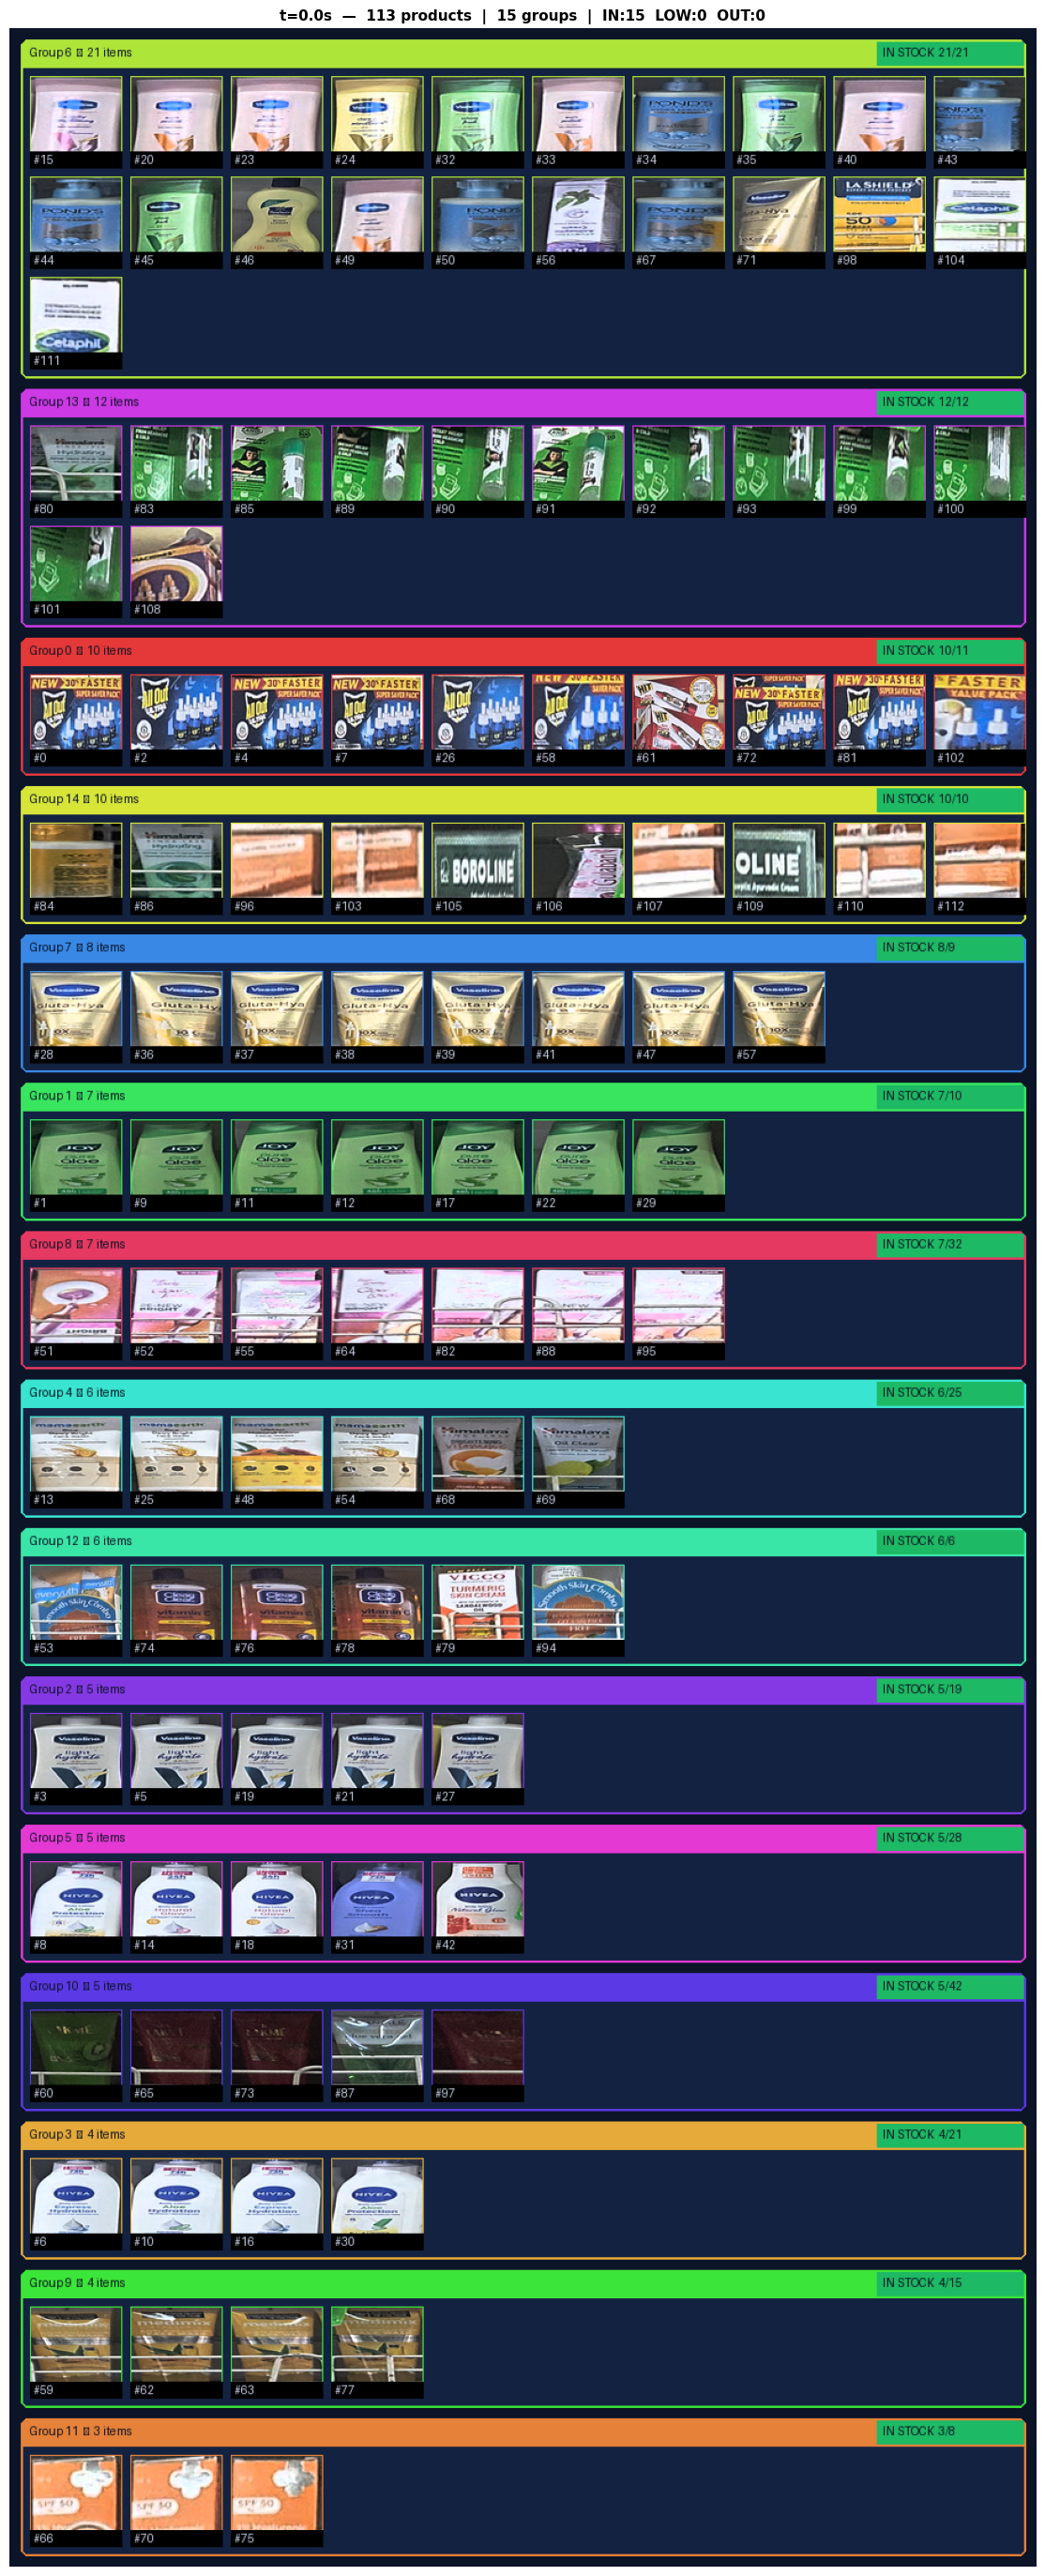

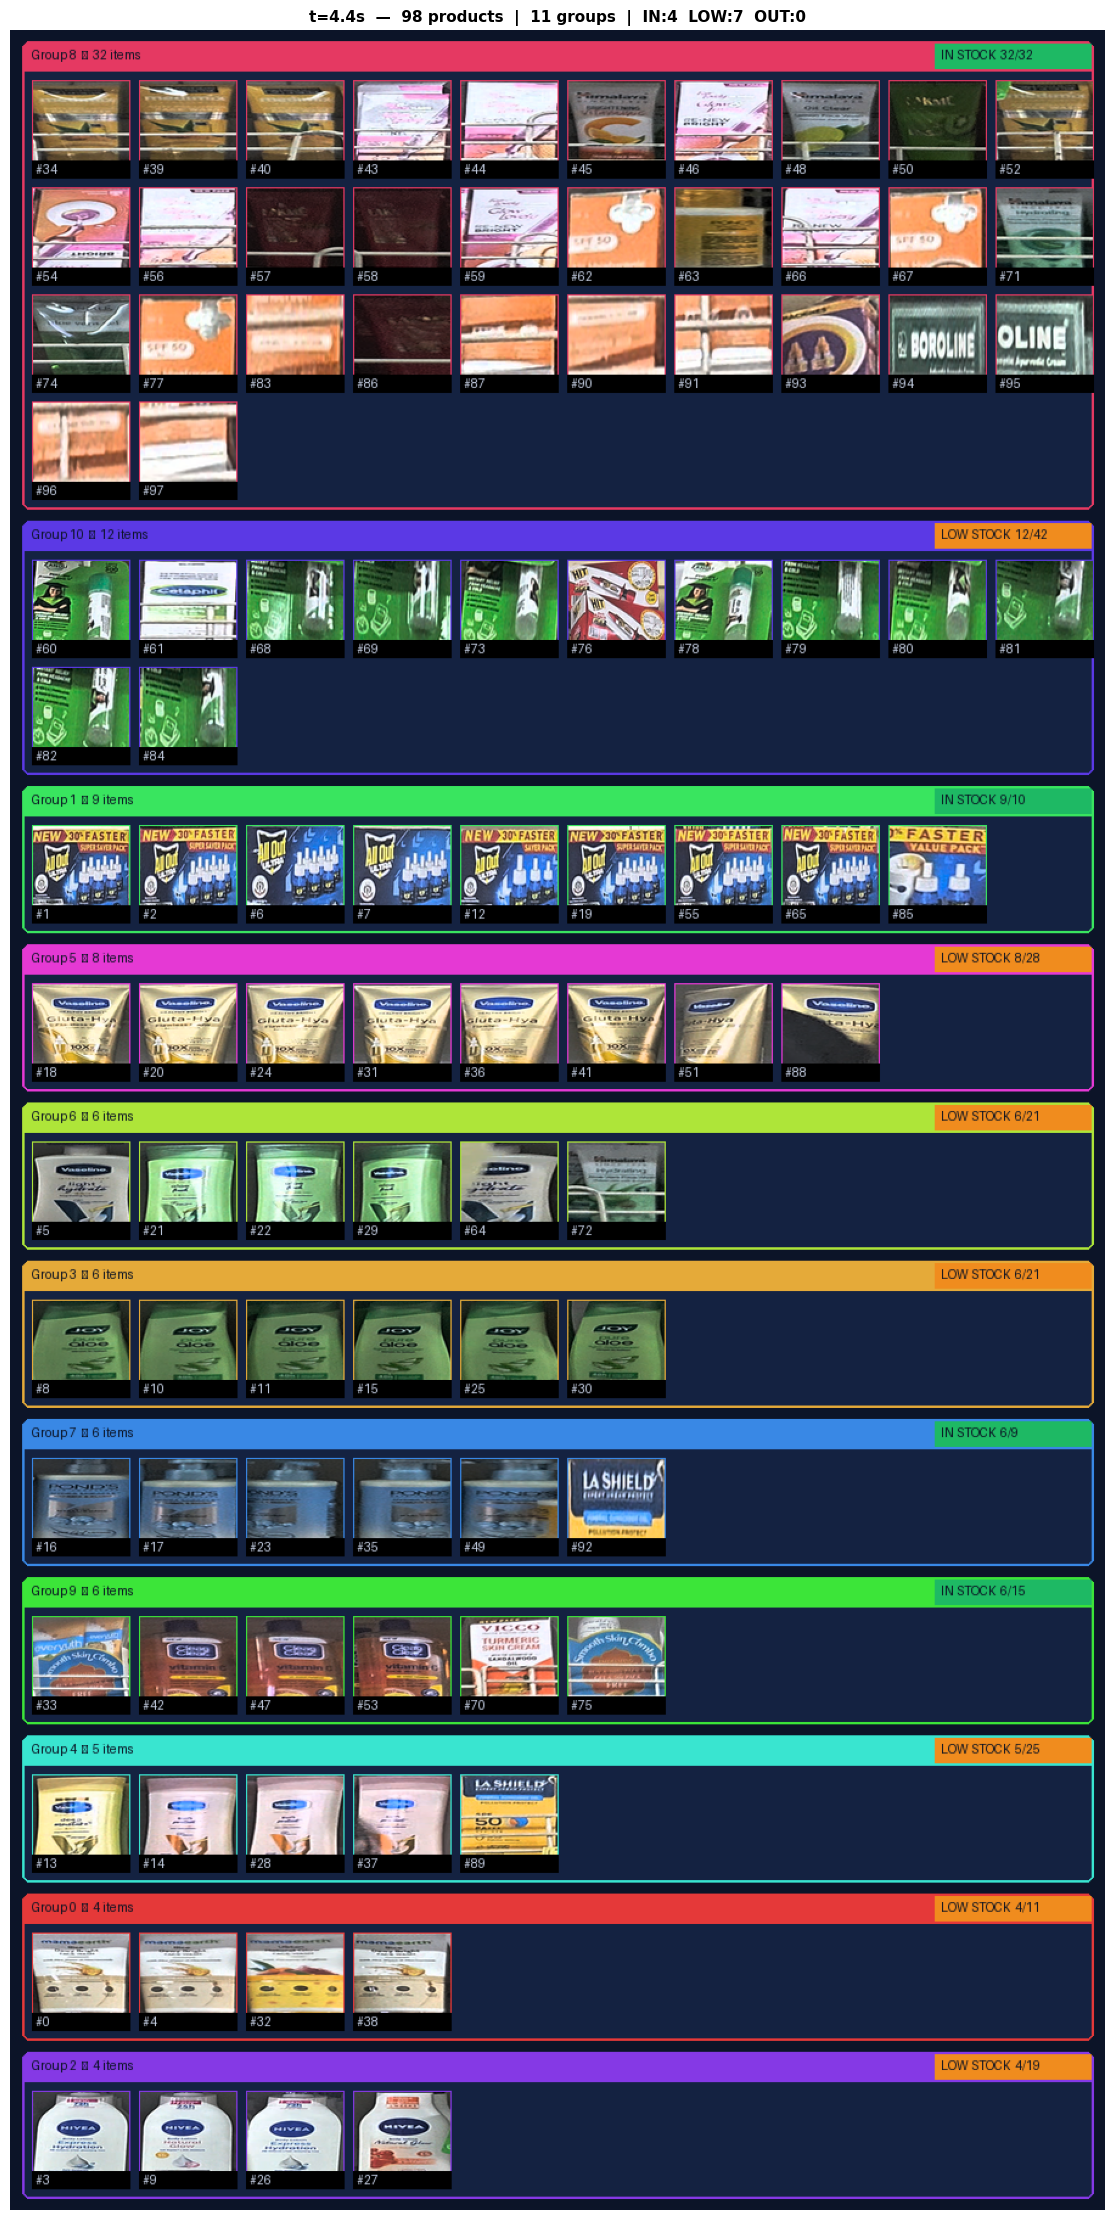

In [15]:
# ============================================================
# CELL 10B - Per-frame group gallery (one frame every 4 seconds)
# ============================================================

THUMB_W, THUMB_H = 80, 80
PADDING          = 8
HEADER_H         = 24
MARGIN           = 10
MAX_PER_ROW      = 10
GALLERY_INTERVAL = 4   # show one frame every N seconds

try:
    fnt_h = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 12)
    fnt_s = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 9)
except:
    fnt_h = fnt_s = ImageFont.load_default()

STATUS_COLORS_RGB = {
    "OUT OF STOCK": (220, 50,  50),
    "LOW STOCK"   : (240, 140, 30),
    "IN STOCK"    : (30,  185, 100),
    "UNKNOWN"     : (150, 150, 150),
}

def gid_to_rgb(gid):
    if gid == -1:
        return (150, 150, 150)
    h = (gid * 0.37) % 1.0
    r, g, b = colorsys.hsv_to_rgb(h, 0.75, 0.90)
    return (int(r*255), int(g*255), int(b*255))

def calc_group_h(n):
    rows = math.ceil(n / MAX_PER_ROW)
    return HEADER_H + rows * (THUMB_H + PADDING) + PADDING


def draw_group_gallery(result, tracker):
    """
    Build and display the group gallery for a single frame result.
    Pulls crops directly from the frame using boxes + labels.
    """
    frame_rgb = result["frame_rgb"]
    boxes     = result["boxes"]
    labels    = result["labels"]
    ts        = result["timestamp"]

    if not boxes or not labels:
        print(f"t={ts:.1f}s — no detections, skipping gallery")
        return

    # rebuild crops from frame + boxes
    crops = [frame_rgb[y1:y2, x1:x2] for x1,y1,x2,y2 in boxes]

    # organise crops by group
    groups = {}
    for i, (crop, gid) in enumerate(zip(crops, labels)):
        groups.setdefault(gid, []).append((i, crop))
    sorted_groups = sorted(groups.items(), key=lambda x: -len(x[1]))

    # canvas size
    total_h  = MARGIN + sum(
        calc_group_h(len(v)) + MARGIN for _, v in sorted_groups
    )
    canvas_w = MARGIN + MAX_PER_ROW * (THUMB_W + PADDING) + MARGIN
    canvas   = Image.new("RGB", (canvas_w, total_h), (12, 20, 40))
    draw_c   = ImageDraw.Draw(canvas)

    cursor_y = MARGIN
    for gid, items in sorted_groups:
        color    = gid_to_rgb(gid)
        status   = result["stock_status"].get(gid, "UNKNOWN")
        sc       = STATUS_COLORS_RGB.get(status, (150,150,150))
        base     = tracker.group_baseline.get(gid, "?")
        cnt      = result["group_counts"].get(gid, 0)
        gh       = calc_group_h(len(items))

        # card background
        draw_c.rounded_rectangle(
            [MARGIN, cursor_y, canvas_w-MARGIN, cursor_y+gh],
            radius=6, fill=(20,34,65), outline=color, width=2
        )
        # header bar
        draw_c.rounded_rectangle(
            [MARGIN, cursor_y, canvas_w-MARGIN, cursor_y+HEADER_H],
            radius=6, fill=color
        )
        draw_c.rectangle(
            [MARGIN, cursor_y+HEADER_H//2,
             canvas_w-MARGIN, cursor_y+HEADER_H],
            fill=color
        )

        # status badge on right of header
        badge_w = 130
        draw_c.rectangle(
            [canvas_w-MARGIN-badge_w, cursor_y+2,
             canvas_w-MARGIN-2,       cursor_y+HEADER_H-2],
            fill=sc
        )
        draw_c.text(
            (canvas_w-MARGIN-badge_w+5, cursor_y+5),
            f"{status}  {cnt}/{base}",
            font=fnt_s, fill=(10,18,35)
        )

        # group label
        label_txt = (f"Group {gid}  —  {len(items)} items"
                     if gid != -1
                     else f"Unmatched  —  {len(items)} items")
        draw_c.text(
            (MARGIN+8, cursor_y+5),
            label_txt, font=fnt_h, fill=(10,18,35)
        )

        # thumbnails
        for idx, (orig_idx, crop) in enumerate(items):
            col = idx % MAX_PER_ROW
            row = idx // MAX_PER_ROW
            tx  = MARGIN + PADDING + col*(THUMB_W+PADDING)
            ty  = cursor_y + HEADER_H + PADDING + row*(THUMB_H+PADDING)

            thumb = Image.fromarray(crop).resize(
                (THUMB_W, THUMB_H), Image.LANCZOS
            )
            canvas.paste(thumb, (tx, ty))
            draw_c.rectangle(
                [tx, ty, tx+THUMB_W, ty+THUMB_H],
                outline=color, width=1
            )
            # index label
            draw_c.rectangle(
                [tx, ty+THUMB_H-14, tx+THUMB_W, ty+THUMB_H],
                fill=(0,0,0)
            )
            draw_c.text(
                (tx+3, ty+THUMB_H-13),
                f"#{orig_idx}", font=fnt_s, fill=(200,210,230)
            )

        cursor_y += gh + MARGIN

    # display
    fig_w = canvas_w / 80
    fig_h = max(total_h / 80, 4)
    plt.figure(figsize=(fig_w, fig_h))
    plt.imshow(np.array(canvas))

    in_s  = sum(1 for s in result["stock_status"].values() if s=="IN STOCK")
    low_s = sum(1 for s in result["stock_status"].values() if s=="LOW STOCK")
    out_s = sum(1 for s in result["stock_status"].values() if s=="OUT OF STOCK")

    plt.title(
        f"t={ts:.1f}s  —  {result['total_count']} products  |  "
        f"{len(sorted_groups)} groups  |  "
        f"IN:{in_s}  LOW:{low_s}  OUT:{out_s}",
        fontsize=11, fontweight="bold"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# ── select one frame every GALLERY_INTERVAL seconds ─────────
if not tracker.history:
    print("No frames processed yet — run Cell 8 first")
else:
    selected    = []
    last_shown  = -GALLERY_INTERVAL  # force first frame to show

    for result in tracker.history:
        if result["timestamp"] - last_shown >= GALLERY_INTERVAL:
            selected.append(result)
            last_shown = result["timestamp"]

    print(f"Showing {len(selected)} frames "
          f"(one every {GALLERY_INTERVAL}s)\n")

    for result in selected:
        draw_group_gallery(result, tracker)

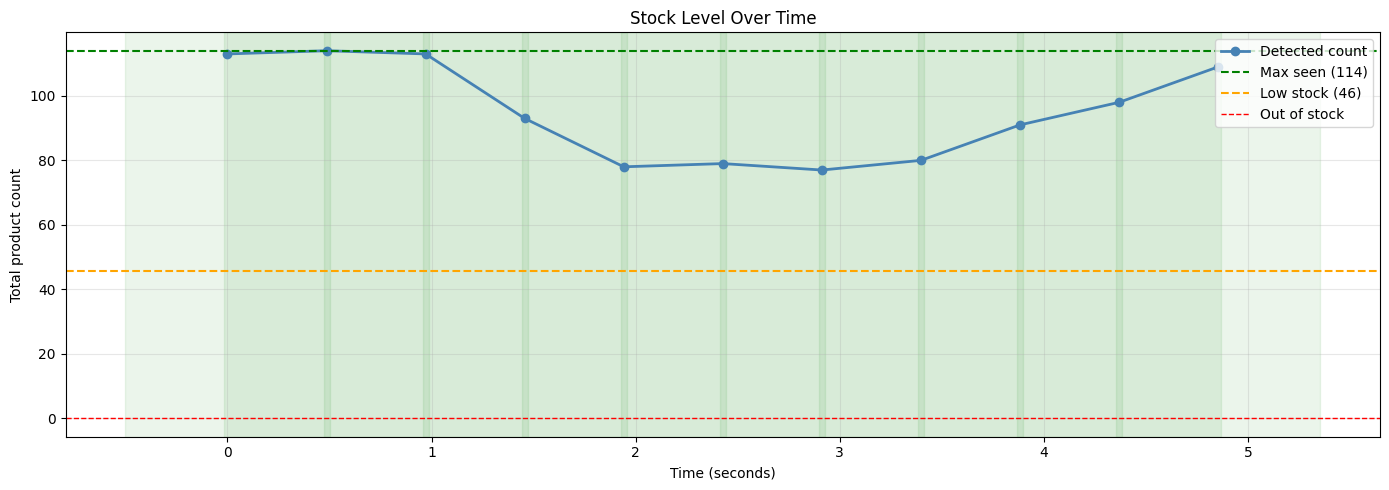

In [16]:
# ============================================================
# CELL 9 - Stock timeline chart
# ============================================================
plot_stock_timeline(tracker)

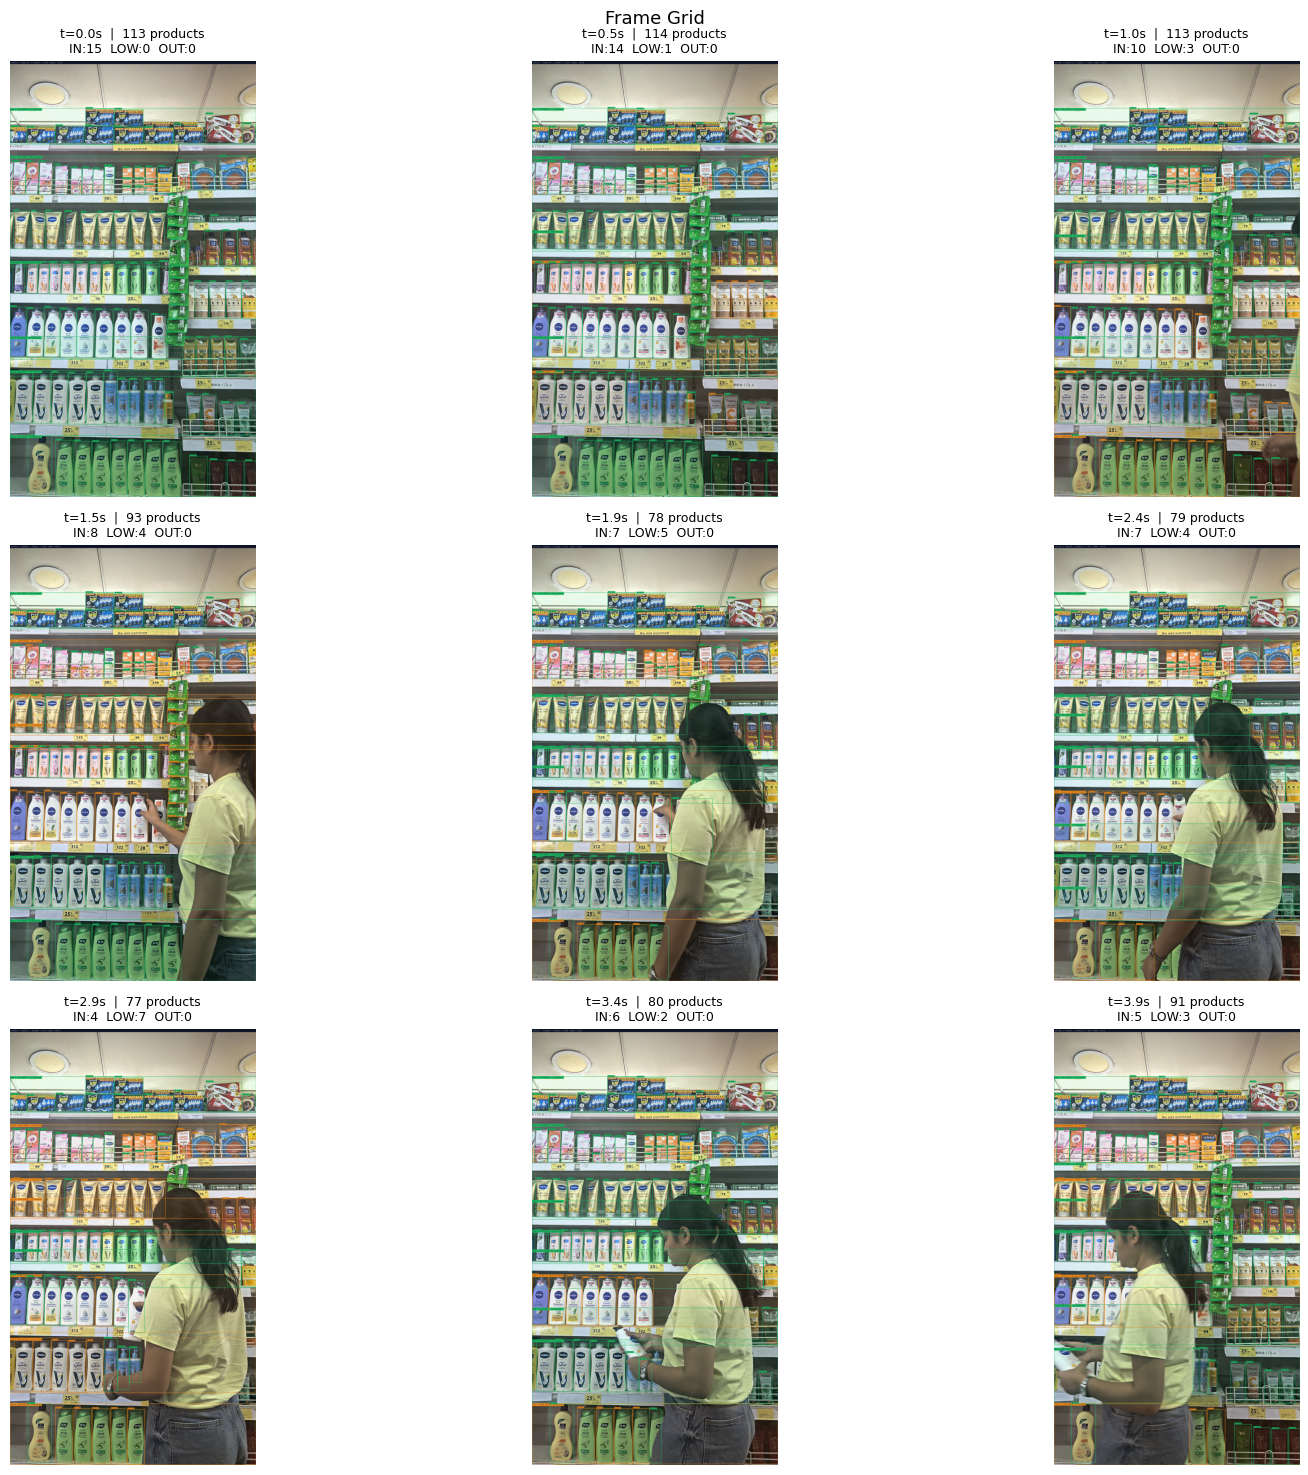

In [17]:
# ============================================================
# CELL 10 - Annotated frame grid
# ============================================================
plot_frame_grid(tracker, max_frames=9)


  STOCK ALERTS
  ⚠️   Group 2    Row 3     Count: 2/19  →  LOW STOCK
  ⚠️   Group 6    Row 3     Count: 5/21  →  LOW STOCK
  ⚠️   Group 4    Row 5     Count: 8/25  →  LOW STOCK
  ⚠️   Group 5    Row 6     Count: 7/28  →  LOW STOCK
  ⚠️   Group 8    Row 5     Count: 6/32  →  LOW STOCK
  ⚠️   Group 10   Row 1     Count: 6/42  →  LOW STOCK
  ⚠️   Group 11   Row 2     Count: 3/8  →  LOW STOCK



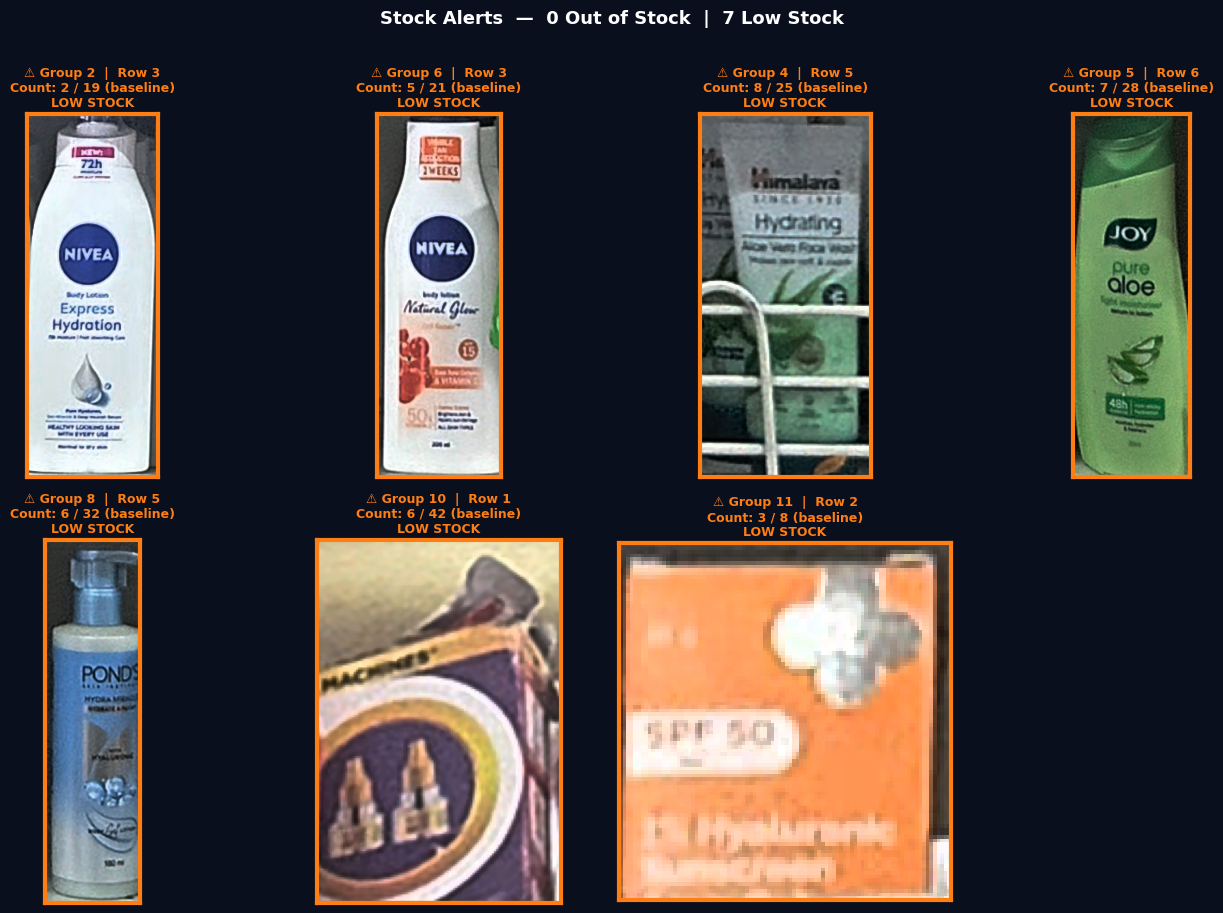

In [18]:
# ============================================================
# CELL 11 - Stock alerts
# Shows image + row number for every OOS and low stock product
# ============================================================

def show_stock_alerts(tracker):
    if not tracker.history:
        print("No frames processed")
        return

    last           = tracker.history[-1]
    stock_status   = last["stock_status"]
    oos_list, low_list = tracker.product_bank.get_alerts(stock_status)
    all_alerts     = (
        [(p, "OUT OF STOCK") for p in oos_list] +
        [(p, "LOW STOCK")    for p in low_list]
    )

    if not all_alerts:
        print("✅  No stock alerts — all products in stock")
        return

    # ── text summary first ────────────────────────────────
    print(f"\n{'='*55}")
    print("  STOCK ALERTS")
    print(f"{'='*55}")
    for product, status in all_alerts:
        row_lbl  = (f"Row {product['row_id']+1}"
                    if product['row_id'] >= 0 else "Row ?")
        baseline = tracker.group_baseline.get(product['group_id'], '?')
        cnt      = last["group_counts"].get(product['group_id'], 0)
        icon     = "🔴" if status == "OUT OF STOCK" else "⚠️ "
        print(f"  {icon}  Group {product['group_id']:<4} "
              f"{row_lbl:<8}  "
              f"Count: {cnt}/{baseline}  →  {status}")
    print(f"{'='*55}\n")

    # ── image grid ────────────────────────────────────────
    COLS = min(4, len(all_alerts))
    ROWS = math.ceil(len(all_alerts) / COLS)

    fig, axes = plt.subplots(
        ROWS, COLS,
        figsize=(COLS * 3.5, ROWS * 4.5),
        facecolor="#0a0f1e"
    )
    axes = np.array(axes).flatten()

    STATUS_HEX = {
        "OUT OF STOCK": "#DC3545",
        "LOW STOCK"   : "#FD7E14",
    }

    for ax, (product, status) in zip(axes, all_alerts):
        gid      = product["group_id"]
        row_id   = product["row_id"]
        crop     = product["last_seen_crop"]
        baseline = tracker.group_baseline.get(gid, "?")
        cnt      = last["group_counts"].get(gid, 0)
        row_lbl  = f"Row {row_id+1}" if row_id >= 0 else "Row ?"
        color    = STATUS_HEX[status]
        icon     = "🔴" if status == "OUT OF STOCK" else "⚠️"

        ax.imshow(crop)
        ax.set_facecolor("#0a0f1e")
        ax.set_title(
            f"{icon} Group {gid}  |  {row_lbl}\n"
            f"Count: {cnt} / {baseline} (baseline)\n"
            f"{status}",
            fontsize=9,
            color=color,
            fontweight="bold",
            pad=6
        )
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

    for ax in axes[len(all_alerts):]:
        ax.set_visible(False)

    plt.suptitle(
        f"Stock Alerts  —  "
        f"{len(oos_list)} Out of Stock  |  "
        f"{len(low_list)} Low Stock",
        fontsize=13, fontweight="bold",
        color="white", y=1.01
    )
    plt.tight_layout()
    plt.show()


show_stock_alerts(tracker)

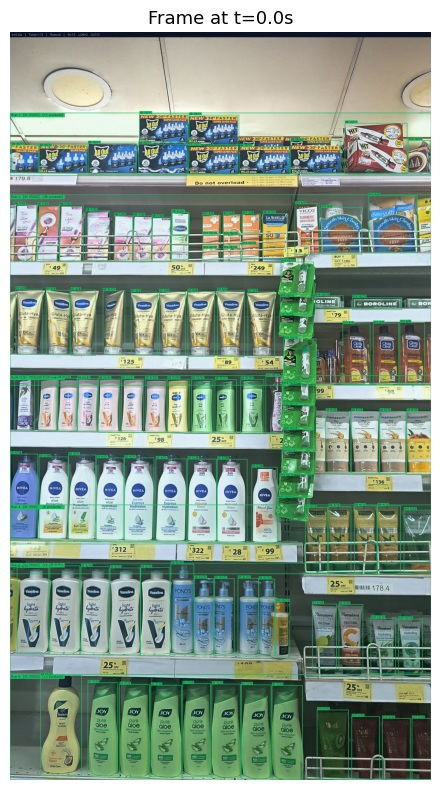


Frame details  (t=0.0s):
──────────────────────────────────────────────────
Group    Row      Count    Baseline   Status
──────────────────────────────────────────────────
0        Row 1    10       11         ✅ IN STOCK
1        Row 6    7        10         ✅ IN STOCK
2        Row 1    5        19         ✅ IN STOCK
3        Row 5    4        21         ✅ IN STOCK
5        Row 5    5        28         ✅ IN STOCK
4        Row 1    6        25         ✅ IN STOCK
6        Row 3    21       21         ✅ IN STOCK
7        Row 1    8        9          ✅ IN STOCK
8        Row 3    7        32         ✅ IN STOCK
12       Row 6    6        6          ✅ IN STOCK
9        Row 6    4        15         ✅ IN STOCK
10       Row 3    5        42         ✅ IN STOCK
11       Row 6    3        8          ✅ IN STOCK
13       Row 3    12       12         ✅ IN STOCK
14       Row 3    10       10         ✅ IN STOCK


In [19]:
# ============================================================
# CELL 12 - Inspect specific frame
# ============================================================
FRAME_INDEX = 0  # change to any index

if FRAME_INDEX < len(tracker.history):
    result    = tracker.history[FRAME_INDEX]
    annotated = draw_annotated_frame(result, tracker)

    plt.figure(figsize=(16,8))
    plt.imshow(annotated)
    plt.title(f"Frame at t={result['timestamp']:.1f}s", fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"\nFrame details  (t={result['timestamp']:.1f}s):")
    print(f"{'─'*50}")
    print(f"{'Group':<8} {'Row':<8} {'Count':<8} "
          f"{'Baseline':<10} {'Status'}")
    print(f"{'─'*50}")
    for gid, status in result["stock_status"].items():
        cnt     = result["group_counts"].get(gid, 0)
        base    = tracker.group_baseline.get(gid, "?")
        row_id  = result["box_to_row"].get(gid, -1)
        row_lbl = f"Row {row_id+1}" if row_id >= 0 else "—"
        icon    = {"IN STOCK":"✅","LOW STOCK":"⚠️ ",
                   "OUT OF STOCK":"🔴"}.get(status, "❓")
        print(f"{gid:<8} {row_lbl:<8} {cnt:<8} "
              f"{str(base):<10} {icon} {status}")
else:
    print(f"Only {len(tracker.history)} frames available")

In [20]:
# ============================================================
# CELL 13 - Save JSON report
# ============================================================
report = {
    "group_baseline" : tracker.group_baseline,
    "total_frames"   : tracker.frame_no,
    "timeline"       : [
        {
            "frame_no"    : r["frame_no"],
            "timestamp"   : round(r["timestamp"], 2),
            "total_count" : r["total_count"],
            "group_counts": r["group_counts"],
            "stock_status": r["stock_status"],
            "row_status"  : {str(k):v
                             for k,v in r["row_status"].items()},
            "group_baseline_snapshot": r["group_baseline_snapshot"],
        }
        for r in tracker.history
    ]
}

REPORT_PATH = "/content/drive/MyDrive/stock_report.json"
with open(REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2)
print(f"Saved → {REPORT_PATH}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/stock_report.json'